This notebook is an exploratory data analysis of a single, denormalized set of training image metadata produced by AWS Athena based on our processed metadata. The primary purpose of this notebook is to understand what the distribution of a few key metadata attributes are that way we can appropriately define thresholds which produce a sufficiently large set of a high quality training data.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
data_label = "localized_time_series_for_training_c02_t1_l2"
glacier_view_dir = os.path.join(os.path.expanduser('~'),"Desktop","projects","GlacierView")
figures_dir = os.path.join(glacier_view_dir, "figures")
metadata_dir = os.path.join(glacier_view_dir,"src","earth_engine","data","processed_metadata",data_label)
plt.style.use(os.path.join(glacier_view_dir,"src", "styles", "ieee.mplstyle"))

In [4]:
df = pd.read_csv(os.path.join(metadata_dir,"denormalized_metadata.csv"))

In [5]:
df.head()

,file_name,glims_id,cloud_cover,image_quality,rank,num_pixels,no_data_pixel_count,zero_pixel_count,percentage_zero_pixels,negative_pixel_count
0,G226793E58723N_2006-08-22_L7_C02_T1_L2_SR.tif,G226793E58723N,86.0,9.0,1,100548,0,13598,0.135239,5093
1,G074481E36741N_2005-08-15_L7_C02_T1_L2_SR.tif,G074481E36741N,1.0,9.0,1,50160,0,9757,0.194518,7710
2,G091131E28428N_2009-11-11_L5_C02_T1_L2_SR.tif,G091131E28428N,0.0,9.0,1,119168,0,2375,0.019930,0
3,G091131E28428N_2009-12-05_L7_C02_T1_L2_SR.tif,G091131E28428N,0.0,9.0,1,119168,0,19647,0.164868,15213
4,G079375E36180N_2009-09-07_L5_C02_T1_L2_SR.tif,G079375E36180N,17.0,9.0,1,66234,0,1214,0.018329,0


In [6]:
df["no_data_pixel_count"].describe()

count    2.722650e+05
mean     1.160384e+03
std      2.498928e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.474491e+06
Name: no_data_pixel_count, dtype: float64

In [7]:
df["image_quality"].value_counts()

image_quality
9.0    255863
7.0     16293
5.0       109
Name: count, dtype: int64

In [8]:
df["percentage_zero_pixels"].max()

0.894736842105263

In [9]:
print("No data pixel count:")
print(f"99th percentile: {np.percentile(df.no_data_pixel_count,95)} | 99.9th percentile: {np.round(np.percentile(df.no_data_pixel_count,99.9),2)}")

print("\n")

print("Negative pixel count:")
print(f"99th percentile: {round(np.percentile(df.negative_pixel_count,40),2)} | 99.9th percentile: {np.round(np.percentile(df.negative_pixel_count,99.9),2)}")


No data pixel count:
99th percentile: 0.0 | 99.9th percentile: 418362.46


Negative pixel count:
99th percentile: 1827.0 | 99.9th percentile: 1127754.09


In [10]:
df.negative_pixel_count.describe()

count    2.722650e+05
mean     2.393435e+04
std      8.516409e+04
min      0.000000e+00
25%      1.200000e+01
50%      4.754000e+03
75%      1.721500e+04
max      4.637315e+06
Name: negative_pixel_count, dtype: float64

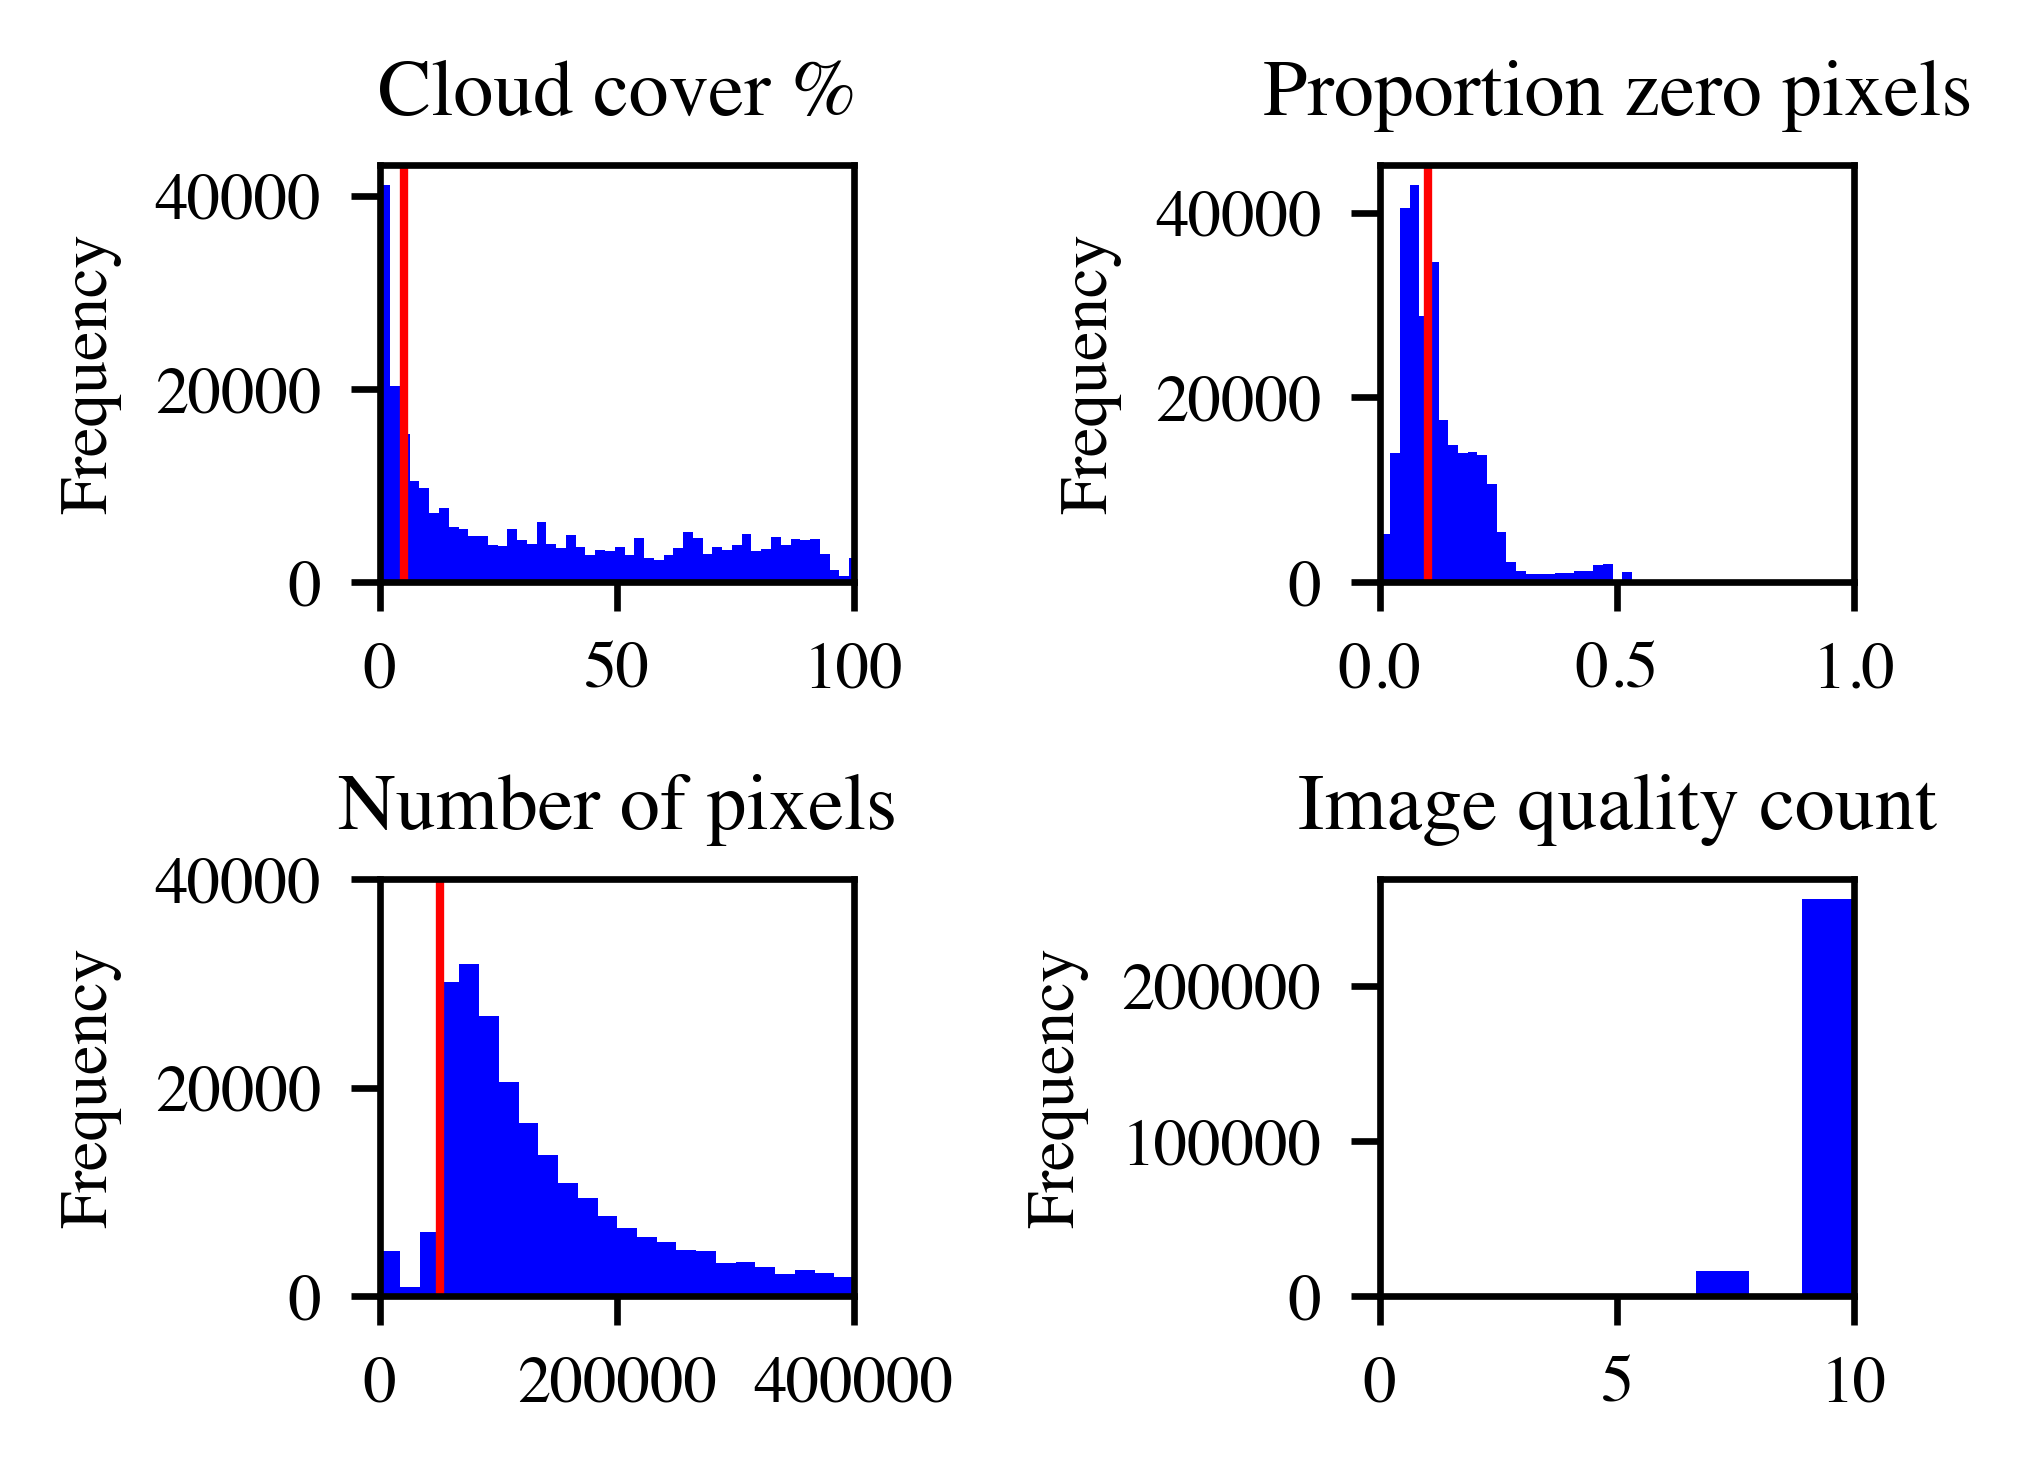

In [19]:
fig, ax = plt.subplots(2,2)

ax[0,0].hist(df["cloud_cover"], bins=np.linspace(0, 101, 50))
ax[0,0].set_xlim(0,100)
ax[0,0].set_title("Cloud cover %")
ax[0,0].axvline(x=5, color='red', linestyle='solid')
ax[0,0].set_ylabel("Frequency")

ax[0,1].hist(df["percentage_zero_pixels"], bins=np.linspace(0, 1, 50))
ax[0,1].set_xlim(0,1)
ax[0,1].set_title("Proportion zero pixels")
ax[0,1].axvline(x=0.1, color='red', linestyle='solid')
ax[0,1].set_ylabel("Frequency")

ax[1,0].hist(df["num_pixels"], bins=np.linspace(0, 400_000, 25))
ax[1,0].set_xlim(0,400_000)
ax[1,0].set_title("Number of pixels")
ax[1,0].axvline(x=50_000, color='red', linestyle='solid')
ax[1,0].set_yticks([0,20_000,40_000])
ax[1,0].set_ylabel("Frequency")

ax[1,1].hist(df["image_quality"], bins = np.linspace(0, 10, 10))
ax[1,1].set_xlim(0,10)
ax[1,1].set_title("Image quality count")
ax[1,1].set_ylabel("Frequency")

fig.tight_layout()
plt.savefig(os.path.join(figures_dir,'distribution_of_metadata.jpg'), dpi=600)
plt.show()